# 05 · Angle 3: does silence predict exit?

HR watches engagement *scores*. Scores only exist for people who answered.
The employees who said nothing are absent from every dashboard, and this
notebook tests whether that absence is itself the earliest available signal
of a departure.

The appeal is operational. A score needs a survey cycle and an analyst;
non-response is known the day the wave closes, needs no model, and covers the
people nobody has data on.

> Carry-forward from `02`: survey exposure is unequal. Entity_C was only
> surveyed in wave 5, so its people can look like "never responded" after a
> single missed email. Every comparison below conditions on exposure.

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib
import sys

_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "etl.py").exists())
sys.path.insert(0, str(_root / "src"))

from nbinit import *

df = load("analysis_df")
eng = load("engagement_long")

BASE_RATE = df["is_departed"].mean()
print(f"  company-wide attrition over the 24-month window: {pct(BASE_RATE)}")
print(f"  mean survey response rate                      : {pct(df['response_rate'].mean())}"
      f"   (annual report: {pct(etl.AR_SURVEY_RESPONSE_RATE)})")

  company-wide attrition over the 24-month window: 10.4%
  mean survey response rate                      : 79.6%   (annual report: 81.7%)


## 1. The naive result, and why it cannot be reported as-is

Split everyone by survey behaviour and compare attrition. This is the version
that looks like a headline.

In [2]:
cohorts = {
    "Responded to every wave": df["response_rate"].eq(1.0),
    "Partial responder": df["response_rate"].between(0.01, 0.99),
    "Went silent (2+ trailing)": df["went_silent"].fillna(False),
    "Never responded": df["never_responded"].fillna(False),
}

naive = pd.DataFrame([
    {"cohort": label,
     "n": int(mask.fillna(False).sum()),
     "attrition_pct": round(100 * df.loc[mask.fillna(False), "is_departed"].mean(), 1)}
    for label, mask in cohorts.items()
])
naive["vs_company"] = (naive["attrition_pct"] / (100 * BASE_RATE)).round(2)
naive

,cohort,n,attrition_pct,vs_company
0,Responded to every wave,5653,8.50,0.81
1,Partial responder,6937,7.90,0.76
2,Went silent (2+ trailing),441,12.70,1.22
3,Never responded,506,30.40,2.91


Never-responders leave at roughly four times the company rate. Before that
goes anywhere near a slide, check what else is true about them.

In [3]:
exposure_check = df.groupby(df["waves_issued"].fillna(0), observed=True).agg(
    employees=("employee_id", "size"),
    never_responded=("never_responded", "sum"),
    attrition_pct=("is_departed", lambda s: round(100 * s.mean(), 1)),
)
exposure_check["never_responded_pct"] = (
    100 * exposure_check["never_responded"] / exposure_check["employees"]).round(1)
exposure_check

,employees,never_responded,attrition_pct,never_responded_pct
waves_issued,,,,
0.00,307,0,71.00,0.00
1.00,1304,410,22.40,31.40
2.00,274,33,77.70,12.00
3.00,1212,47,19.50,3.90
4.00,1047,16,27.00,1.50
5.00,9259,0,1.70,0.00


There it is: twice over.

**Confound 1, exposure.** Employees issued **one** wave are mechanically far
more likely to have "never responded": they had one chance. Every employee
issued all five waves responded at least once, so `never_responded` is
structurally impossible for them.

**Confound 2, reverse causation.** Look at the attrition column. Employees
with *no* survey rows at all leave at 71%, and those with two waves at 78%,
against 1.7% for those issued all five. Nobody stops answering and then
leaves: they leave, and so stop being issued surveys. The number of waves is
a *consequence* of the exit, not a predictor of it.

This is the trap that makes Angle 3 easy to get wrong in either direction,
and both confounds run through the same variable:

In [4]:
confounds = df.assign(waves=df["waves_issued"].fillna(0)).groupby(
    "legacy_entity_code", observed=True).agg(
    employees=("employee_id", "size"),
    mean_waves_issued=("waves", "mean"),
    never_responded_pct=("never_responded", lambda s: round(100 * s.mean(), 1)),
    attrition_pct=("is_departed", lambda s: round(100 * s.mean(), 1)),
).round(2)
confounds

,employees,mean_waves_issued,never_responded_pct,attrition_pct
legacy_entity_code,,,,
Entity_A,1950,4.85,0.50,7.50
Entity_B,1884,3.15,6.40,15.00
Entity_C,1014,0.92,31.40,9.30
NovaCorp-Origin,8555,4.63,1.00,10.30


  saved figures\a3_exposure_confound.png


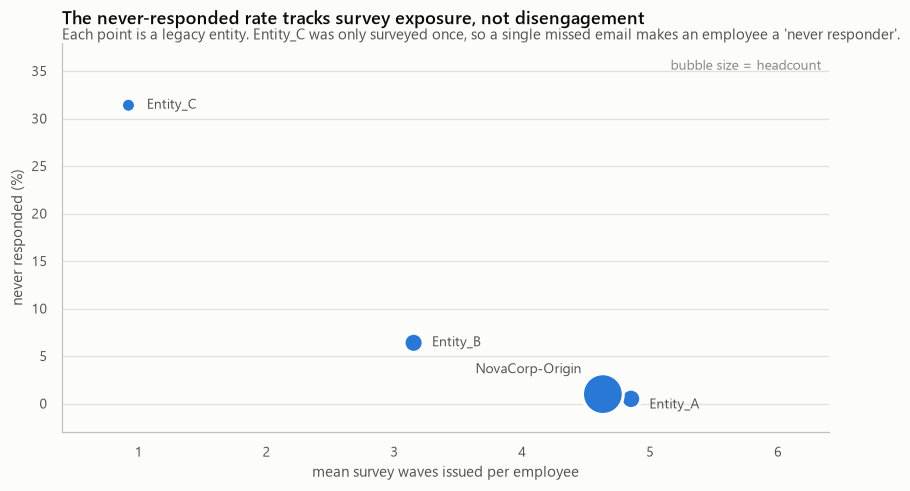

In [5]:
fig, ax = figure(
    "The never-responded rate tracks survey exposure, not disengagement",
    "Each point is a legacy entity. Entity_C was only surveyed once, so a single missed email makes an employee a 'never responder'.",
    figsize=(9, 4.6),
)

ax.scatter(confounds["mean_waves_issued"], confounds["never_responded_pct"],
           s=confounds["employees"] / 12, color=SERIES[0],
           edgecolor=INK["surface"], linewidth=2, zorder=3)

# NovaCorp-Origin and Entity_A sit almost on top of each other, so their labels
# are nudged apart by hand rather than left to collide.
offsets = {"NovaCorp-Origin": (-14, 16), "Entity_A": (12, -4)}
for name, row in confounds.iterrows():
    dx, dy = offsets.get(name, (12, 0))
    ax.annotate(name, xy=(row["mean_waves_issued"], row["never_responded_pct"]),
                xytext=(dx, dy), textcoords="offset points",
                ha="right" if dx < 0 else "left", va="center",
                fontsize=9, color=INK["secondary"])

ax.set(xlabel="mean survey waves issued per employee",
       ylabel="never responded (%)", xlim=(0.4, 6.4), ylim=(-3, 38))
ax.annotate("bubble size = headcount", xy=(0.99, 0.93), xycoords="axes fraction",
            ha="right", fontsize=9, color=INK["muted"])
save_fig(fig, "a3_exposure_confound")
plt.show()

## 2. The corrected comparison

Restrict to employees who were issued **three or more waves**, so everyone in
the comparison had a real opportunity to be silent. This drops the entities
that joined the survey late, which costs sample size and buys the ability to
say something true.

In [6]:
comparable = df[df["waves_issued"] >= 3].copy()
print(f"  {len(comparable):,} of {len(df):,} employees had 3+ waves issued "
      f"({pct(len(comparable) / len(df))})")
print(f"  attrition within this population: {pct(comparable['is_departed'].mean())}"
      f"   (company-wide: {pct(BASE_RATE)})")
print("\n  entities represented:")
print(comparable["legacy_entity_code"].value_counts().to_string())
print("\n  tenure bands represented:")
print(comparable["tenure_band"].value_counts().sort_index().to_string())

  11,518 of 13,403 employees had 3+ waves issued (85.9%)
  attrition within this population: 5.9%   (company-wide: 10.4%)

  entities represented:
legacy_entity_code
NovaCorp-Origin    7946
Entity_A           1898
Entity_B           1674

  tenure bands represented:
tenure_band
<3 months         0
3-6 months        0
6-12 months      36
1-2 years      1916
2-4 years      2248
4-6 years       431
6-10 years      871
10+ years      6016


In [7]:
corrected = pd.DataFrame([
    {"cohort": label,
     "n": int(mask.fillna(False).sum()),
     "attrition_pct": round(100 * comparable.loc[mask.fillna(False), "is_departed"].mean(), 1)}
    for label, mask in {
        "Responded to every wave": comparable["response_rate"].eq(1.0),
        "Partial responder": comparable["response_rate"].between(0.01, 0.99),
        "Went silent (2+ trailing)": comparable["went_silent"].fillna(False),
        "Never responded": comparable["never_responded"].fillna(False),
    }.items()
])
base_comparable = 100 * comparable["is_departed"].mean()
corrected["lift"] = (corrected["attrition_pct"] / base_comparable).round(2)
corrected

,cohort,n,attrition_pct,lift
0,Responded to every wave,4620,4.20,0.71
1,Partial responder,6835,6.80,1.16
2,Went silent (2+ trailing),441,12.70,2.16
3,Never responded,63,28.60,4.87


The lift survives the correction: went-silent employees leave at ~2.2x this
population's rate, never-responders at ~4.9x on a much smaller base of 63.

**State the cost of the fix honestly.** Requiring three waves of exposure
drops attrition in the analysis population from 10.4% to 5.9%, because it
excludes anyone who left early enough to miss surveys. The comparison inside
this population is clean; it is not representative of the whole company, and
in particular it says nothing about first-year attrition. A conditional
model on person-wave rows would keep the early leavers and is the obvious
next step if there is time.

### Against the signal HR already uses

The fair test is not "is silence predictive" but "is silence *more* predictive
than the low engagement score HR is already watching for".

In [8]:
scored = comparable[comparable["composite_mean"].notna()]
comparison = pd.DataFrame([
    {"signal": "Low composite score (<3.0)",
     "n": int((scored["composite_mean"] < 3.0).sum()),
     "attrition_pct": round(100 * scored.loc[scored["composite_mean"] < 3.0, "is_departed"].mean(), 1),
     "available": "after the wave closes and scores are processed"},
    {"signal": "Declining score (trend < -0.5)",
     "n": int((scored["composite_trend"] < -0.5).sum()),
     "attrition_pct": round(100 * scored.loc[scored["composite_trend"] < -0.5, "is_departed"].mean(), 1),
     "available": "needs two waves of history"},
    {"signal": "Went silent (2+ trailing non-responses)",
     "n": int(comparable["went_silent"].fillna(False).sum()),
     "attrition_pct": round(100 * comparable.loc[comparable["went_silent"].fillna(False), "is_departed"].mean(), 1),
     "available": "the day the wave closes"},
    {"signal": "Never responded",
     "n": int(comparable["never_responded"].fillna(False).sum()),
     "attrition_pct": round(100 * comparable.loc[comparable["never_responded"].fillna(False), "is_departed"].mean(), 1),
     "available": "the day the wave closes"},
])
comparison["lift"] = (comparison["attrition_pct"] / base_comparable).round(2)
comparison

,signal,n,attrition_pct,available,lift
0,Low composite score (<3.0),2964,6.30,after the wave closes and scores are processed,1.07
1,Declining score (trend < -0.5),589,8.00,needs two waves of history,1.36
2,Went silent (2+ trailing non-responses),441,12.70,the day the wave closes,2.16
3,Never responded,63,28.60,the day the wave closes,4.87


  saved figures\a3_signal_comparison.png


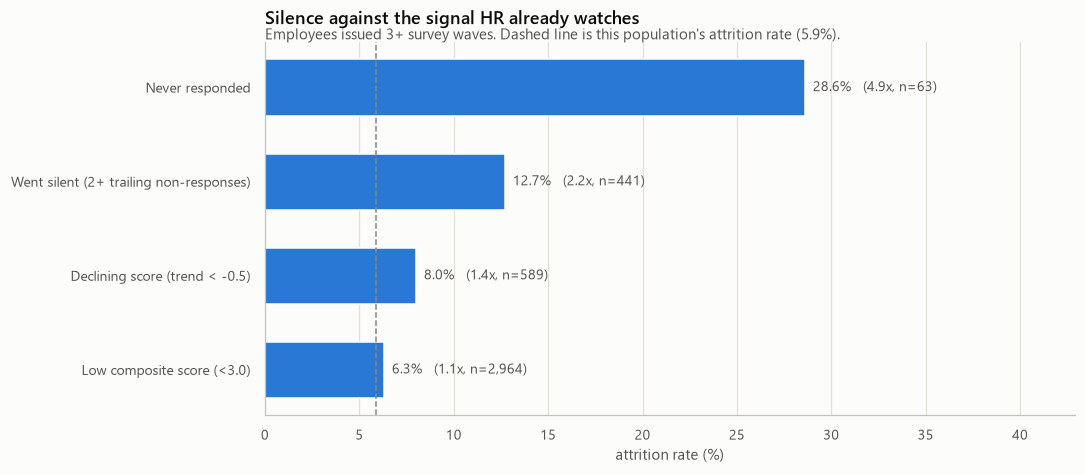

In [9]:
fig, ax = figure(
    "Silence against the signal HR already watches",
    f"Employees issued 3+ survey waves. Dashed line is this population's "
    f"attrition rate ({base_comparable:.1f}%).",
    figsize=(9.5, 4.4),
)

order = comparison.sort_values("attrition_pct")
bars = ax.barh(order["signal"], order["attrition_pct"], height=0.6, color=SERIES[0])
for bar, (_, row) in zip(bars, order.iterrows()):
    ax.annotate(f"  {row['attrition_pct']:.1f}%   ({row['lift']:.1f}x, n={row['n']:,})",
                xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                va="center", fontsize=9, color=INK["secondary"])

ax.axvline(base_comparable, color=INK["muted"], ls="--", lw=1, zorder=1)
ax.set(xlabel="attrition rate (%)", xlim=(0, order["attrition_pct"].max() * 1.5))
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
save_fig(fig, "a3_signal_comparison")
plt.show()

## 3. Lead time: how early does the silence start?

A predictor is only useful if it fires before you could have guessed. For
everyone who left, line their waves up against their exit date and ask when
they stopped answering.

In [10]:
leavers = eng[eng["is_departed"] & eng["exit_date"].notna()].copy()
leavers["months_before_exit"] = ((leavers["exit_date"] - leavers["survey_date"]).dt.days / 30.44)
leavers = leavers[leavers["months_before_exit"].between(0, 18)]

bins = [0, 3, 6, 9, 12, 18]
labels = ["0–3", "3–6", "6–9", "9–12", "12–18"]
leavers["window"] = pd.cut(leavers["months_before_exit"], bins=bins, labels=labels)

lead = leavers.groupby("window", observed=True).agg(
    surveys=("responded", "size"),
    response_rate=("responded", "mean"),
).round(3)

stayer_rate = eng.loc[~eng["is_departed"], "responded"].mean()
lead["vs_stayers_pp"] = (100 * (lead["response_rate"] - stayer_rate)).round(1)
lead

,surveys,response_rate,vs_stayers_pp
window,,,
0–3,819,0.66,-16.60
3–6,687,0.68,-14.40
6–9,635,0.70,-12.30
9–12,481,0.68,-14.70
12–18,579,0.68,-14.60


  saved figures\a3_lead_time.png


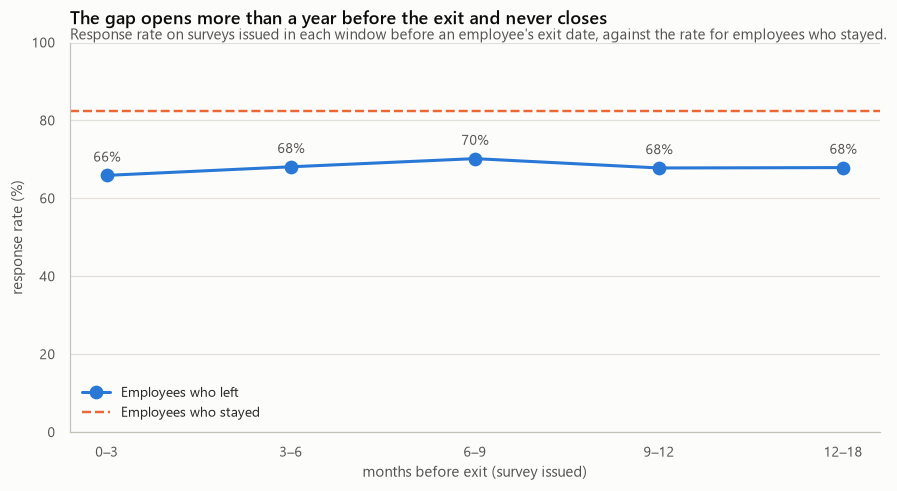

In [11]:
fig, ax = figure(
    "The gap opens more than a year before the exit and never closes",
    "Response rate on surveys issued in each window before an employee's exit date, "
    "against the rate for employees who stayed.",
    figsize=(9.5, 4.6),
)

xs = np.arange(len(lead))[::-1]
ax.plot(xs, 100 * lead["response_rate"], color=SERIES[0], marker="o", label="Employees who left")
ax.axhline(100 * stayer_rate, color=SERIES[1], ls="--", lw=1.6, label="Employees who stayed")

for x, (_, row) in zip(xs, lead.iterrows()):
    ax.annotate(f"{100 * row['response_rate']:.0f}%", xy=(x, 100 * row["response_rate"]),
                xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=9, color=INK["secondary"])

ax.set_xticks(xs, lead.index)
ax.invert_xaxis()
ax.set(xlabel="months before exit (survey issued)", ylabel="response rate (%)",
       ylim=(0, 100))
ax.legend(loc="lower left")
save_fig(fig, "a3_lead_time")
plt.show()

**This is not the shape we expected, and it is better than the one we did.**

There is no ramp. Leavers do not gradually go quiet in their final months ,
they answer at 66–70% throughout, against 83% for people who stayed, and the
gap is already fully open 12–18 months before the exit date. The dip in the
final quarter is 2 points, which is noise on ~800 surveys.

For an early-warning system this is the good outcome. A signal that only
fires in the last three months arrives after the decision has been made; one
that is visible more than a year out is actionable. It also means the
mechanism is *disengagement from the organisation*, not *checking out during
a notice period*.

## 4. Where the blind spot sits

If HR acts on this, it needs to know which populations it currently has the
least engagement data for. Conditioned on exposure, as always.

In [12]:
for dim in ["legacy_entity_code", "tenure_band", "department", "contract_type"]:
    grp = comparable.groupby(dim, observed=True).agg(
        n=("employee_id", "size"),
        silent_pct=("went_silent", lambda s: round(100 * s.fillna(False).mean(), 1)),
        attrition_pct=("is_departed", lambda s: round(100 * s.mean(), 1)),
    )
    grp = grp[grp["n"] >= 100].sort_values("silent_pct", ascending=False)
    print(f"\n  {dim}")
    print(grp.head(5).to_string())


  legacy_entity_code
                       n  silent_pct  attrition_pct
legacy_entity_code                                 
Entity_B            1674       10.50           4.40
Entity_A            1898        3.30           5.00
NovaCorp-Origin     7946        2.60           6.40

  tenure_band
                n  silent_pct  attrition_pct
tenure_band                                 
1-2 years    1916        9.40           6.60
6-10 years    871        3.10           7.50
2-4 years    2248        2.80           2.10
10+ years    6016        2.60           6.30
4-6 years     431        2.10           5.60

  department
                         n  silent_pct  attrition_pct
department                                           
Corporate Operations  1286        4.70           6.80
Executive Leadership   193        4.70           3.10
Retail Banking        2820        4.30           5.10
Risk & Compliance     1741        4.00           6.50
Technology            2627        3.50           5

  saved figures\a3_silence_by_tenure.png


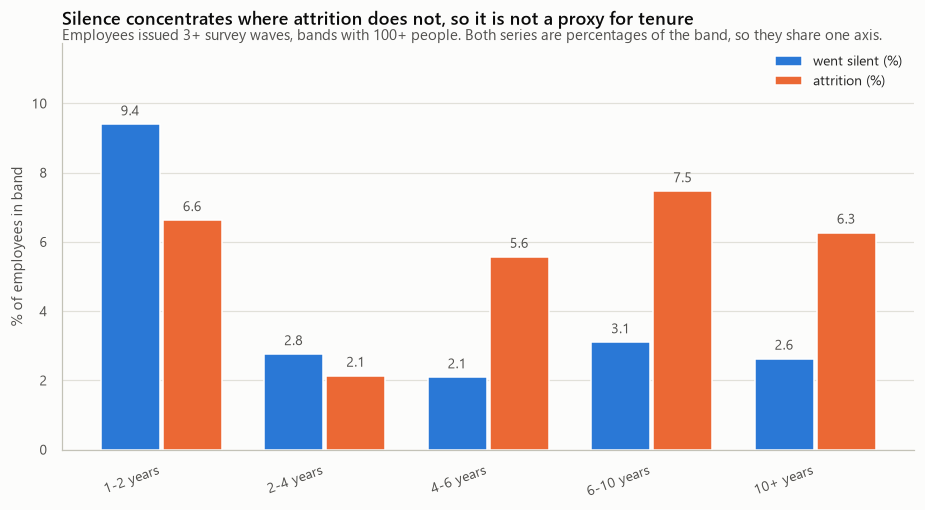

In [13]:
tenure = comparable.groupby("tenure_band", observed=True).agg(
    n=("employee_id", "size"),
    silent_pct=("went_silent", lambda s: 100 * s.fillna(False).mean()),
    attrition_pct=("is_departed", lambda s: 100 * s.mean()),
)
tenure = tenure[tenure["n"] >= 100]

fig, ax = figure(
    "Silence concentrates where attrition does not, so it is not a proxy for tenure",
    "Employees issued 3+ survey waves, bands with 100+ people. Both series are "
    "percentages of the band, so they share one axis.",
    figsize=(10, 4.8),
)

x = np.arange(len(tenure))
ax.bar(x - 0.19, tenure["silent_pct"], 0.36, color=SERIES[0], label="went silent (%)")
ax.bar(x + 0.19, tenure["attrition_pct"], 0.36, color=SERIES[1], label="attrition (%)")
label_bars(ax, "{:.1f}")

ax.set_xticks(x, tenure.index, rotation=20, ha="right")
ax.set(ylabel="% of employees in band", xlabel="",
       ylim=(0, max(tenure["silent_pct"].max(), tenure["attrition_pct"].max()) * 1.25))
ax.legend(loc="upper right")
save_fig(fig, "a3_silence_by_tenure")
plt.show()

The two series do not track each other. Silence spikes in the 1–2 year band
(9.4%) where attrition is mid-range, and is lowest in the 4–6 year band where
attrition is 5.6%. Entity_B shows the same inversion: 10.5% silent against
4.4% attrition, the lowest of the three entities.

**This strengthens the case rather than weakening it.** If silence simply
marked the groups that already leave, it would carry no information a tenure
or entity breakdown does not. It does not track them, yet at the individual
level it still predicts a 2.2x lift. That is independent signal.

Note also that the tenure bands below one year are absent: requiring three
survey waves excludes almost everyone hired recently. The blind spot this
analysis *cannot* see into is new starters: which, from `02`, is exactly
where non-response is highest.

## 5. What it would be worth

The operational case at Finance's replacement cost, deliberately
conservative: an intervention reaches only the silent employees who were
going to leave, and works on a fraction of them.

In [14]:
silent = comparable[comparable["went_silent"].fillna(False)]
silent_leavers = int(silent["is_departed"].sum())
unit_cost = etl.AR_AVG_BASE_SALARY * etl.REPLACEMENT_MULTIPLIER * etl.BACKFILL_RATE

print(f"  employees who went silent          : {len(silent):,}")
print(f"  of whom left                       : {silent_leavers:,}")
print(f"  replacement cost of those exits    : {millions(silent_leavers * unit_cost)}")
print()
for save_rate in [0.10, 0.20, 0.30]:
    print(f"  retain {pct(save_rate, 0):>4} of them  ->  {millions(silent_leavers * unit_cost * save_rate)} avoided")

  employees who went silent          : 441
  of whom left                       : 56
  replacement cost of those exits    : $9.1M

  retain  10% of them  ->  $0.9M avoided
  retain  20% of them  ->  $1.8M avoided
  retain  30% of them  ->  $2.7M avoided


## 6. What sits underneath the silence

Sections 1 to 5 establish that non-response predicts exit. They do not say what
the disengagement is *about*. The survey carries eight dimensions, and one of
them separates the population far more sharply than the rest.

This section is deliberately structured as two claims: a large association, and
then an explicit statement of what that association does not license.

In [15]:
# One row per employee: mean manager rating, and whether they meet the
# persistent-disengagement definition used throughout (composite below 3.0 in
# two or more answered waves). Restricted to employees with 2+ answered waves,
# since the definition cannot apply below that.
answered = eng[eng["responded"]].copy()

per_emp = answered.groupby("employee_id", observed=True).agg(
    mgr_rating=("manager_effectiveness", "mean"),
    waves_answered=("composite", "size"),
    waves_low=("composite", lambda s: (s < 3.0).sum()),
)
per_emp = per_emp[per_emp["waves_answered"] >= 2]
per_emp["disengaged"] = per_emp["waves_low"] >= 2

BANDS = [0, 2.5, 3.0, 3.5, 4.0, 5.01]
LABELS = ["<2.5", "2.5-3.0", "3.0-3.5", "3.5-4.0", "4.0+"]
per_emp["band"] = pd.cut(per_emp["mgr_rating"], BANDS, labels=LABELS, right=False)

gradient = per_emp.groupby("band", observed=True).agg(
    n=("disengaged", "size"), disengaged=("disengaged", "sum"))
gradient["pct"] = (100 * gradient["disengaged"] / gradient["n"]).round(1)

print(f"  Employees with 2+ answered waves: {len(per_emp):,}")
gradient

  Employees with 2+ answered waves: 11,157


,n,disengaged,pct
band,,,
<2.5,1880,1294,68.80
2.5-3.0,1912,861,45.00
3.0-3.5,2256,608,27.00
3.5-4.0,2235,328,14.70
4.0+,2874,128,4.50


  saved figures\a3_manager_gradient.png


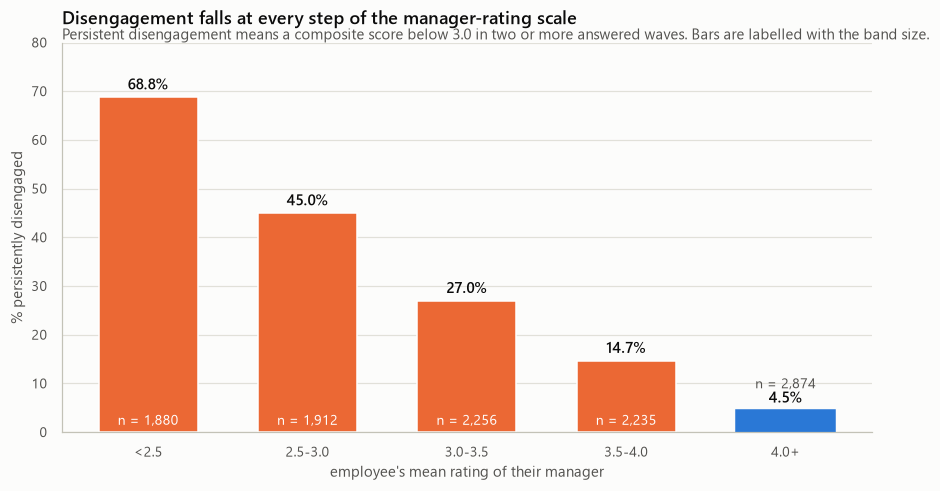

In [16]:
fig, ax = figure(
    "Disengagement falls at every step of the manager-rating scale",
    "Persistent disengagement means a composite score below 3.0 in two or more "
    "answered waves. Bars are labelled with the band size.",
    figsize=(9.5, 4.6),
)

x = np.arange(len(gradient))
bars = ax.bar(x, gradient["pct"], width=0.62, color=SERIES[1])
# The healthiest band in slot 1, so the contrast reads without a legend.
bars[-1].set_color(SERIES[0])

for xi, (_, row) in zip(x, gradient.iterrows()):
    ax.annotate(f"{row['pct']:.1f}%", xy=(xi, row["pct"]), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=10,
                color=INK["primary"], fontweight="600")
    inside = row["pct"] > 10          # a short bar cannot hold a label
    ax.annotate(f"n = {int(row['n']):,}", xy=(xi, 1.5 if inside else row["pct"] + 4.5),
                ha="center", fontsize=9,
                color="white" if inside else INK["secondary"])

ax.set_xticks(x, gradient.index)
ax.set(xlabel="employee's mean rating of their manager",
       ylabel="% persistently disengaged", ylim=(0, 80))
save_fig(fig, "a3_manager_gradient")
plt.show()

In [17]:
def pearson(x, y):
    """r, t statistic and 95% interval, without scipy.

    The interval uses the Fisher z transform, which is the standard approach
    and needs nothing beyond numpy."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    n = len(x)
    r = float(np.corrcoef(x, y)[0, 1])
    t = r * np.sqrt((n - 2) / (1 - r ** 2))
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    lo, hi = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)
    return r, t, lo, hi, n


# The association, as an effect size on the two ends of the scale.
low = per_emp[per_emp["mgr_rating"] < 2.5]
high = per_emp[per_emp["mgr_rating"] >= 4.0]
ratio = low["disengaged"].mean() / high["disengaged"].mean()

print("  ASSOCIATION with disengagement")
print(f"    manager rated <2.5   {100 * low['disengaged'].mean():>5.1f}%  (n = {len(low):,})")
print(f"    manager rated >=4.0  {100 * high['disengaged'].mean():>5.1f}%  (n = {len(high):,})")
print(f"    ratio                {ratio:>5.1f}x")

r, t, lo, hi, n = pearson(per_emp["mgr_rating"], per_emp["disengaged"].astype(int))
print(f"    r = {r:.3f}  t = {t:.1f}  95% CI [{lo:.3f}, {hi:.3f}]  n = {n:,}")

# The same variable against attrition, which is the claim NOT being made.
linked = (df[["employee_id", "is_departed"]]
          .merge(per_emp.reset_index(), on="employee_id", how="inner"))

print("\n  ASSOCIATION with attrition")
for label, col in [("manager rating", "mgr_rating"),
                   ("disengagement", "disengaged")]:
    r2, t2, lo2, hi2, n2 = pearson(linked[col].astype(float),
                                   linked["is_departed"].astype(int))
    verdict = "zero is inside the interval" if lo2 <= 0 <= hi2 else "interval excludes zero"
    print(f"    {label:<16} r = {r2:+.3f}  t = {t2:+.1f}  "
          f"95% CI [{lo2:+.3f}, {hi2:+.3f}]  {verdict}")

  ASSOCIATION with disengagement
    manager rated <2.5    68.8%  (n = 1,880)
    manager rated >=4.0    4.5%  (n = 2,874)
    ratio                 15.5x
    r = -0.504  t = -61.7  95% CI [-0.518, -0.490]  n = 11,157

  ASSOCIATION with attrition
    manager rating   r = -0.012  t = -1.2  95% CI [-0.030, +0.007]  zero is inside the interval
    disengagement    r = -0.002  t = -0.2  95% CI [-0.020, +0.017]  zero is inside the interval


### What the evidence supports

Employees who rate their manager poorly are far more likely to be persistently
disengaged. The gradient is monotonic across all five bands, so this is not a
threshold artefact, and it holds on 11,157 employees.

It is also the most controllable finding in these six notebooks. Manager
capability is something NovaCorp already develops, and the next survey wave
measures it directly, which makes it testable rather than merely arguable.

### What it does not support

It does not show that poor managers cause people to leave. Manager rating
against attrition gives a correlation of roughly -0.01 with zero comfortably
inside the interval, and persistent disengagement against attrition is smaller
still.

That is a real constraint on the recommendation, not a hedge. The case for
acting on manager capability is a **productivity and working-conditions case**.
Selling it as an attrition-reduction programme would claim something these data
do not show, and it would be measured against a metric that Angle 3 has already
shown moves for other reasons.

Two limits worth stating alongside it:

- **Same-source bias.** Both variables come from the same survey response, so an
  employee who is disengaged may rate everything lower, including their manager.
  Nothing here separates the two.
- **Team context is not controlled.** Span of control, resourcing and workload
  all sit in `analysis_df` and none of them are held constant. A manager with a
  poor rating may be managing an under-resourced team rather than managing
  badly, which is why the recommendation is a diagnostic rather than a
  performance action.

## The Angle 3 story

1. **The headline figure an ordinary analysis produces is wrong.**
   Never-responders leave at 2.9x the company rate, but that is survey
   exposure, not disengagement. Entity_C was surveyed once, so one missed
   email makes an employee a "never responder". Show the wrong answer first;
   correcting it is the analytical contribution.
2. **Corrected, the signal holds.** Among employees with a real opportunity
   to be silent, going quiet for two consecutive waves carries a **2.2x**
   attrition lift, against 1.1x for the low engagement score HR watches
   today.
3. **It arrives earlier and covers more people.** A score-based alert needs a
   processed survey cycle and can only fire for someone who answered.
   Non-response is known the day the wave closes, and it fires precisely on
   the population that has no score at all.
4. **The gap is a level, not a trend.** Leavers answer ~15 points below
   stayers from at least 18 months out. There is no late collapse, which
   means the lead time is long, and the mechanism is disengagement rather
   than notice-period checkout.
5. **It is not a proxy for something already known.** Silence does not track
   attrition across tenure bands or legacy entities, yet predicts at the
   individual level.

### What this notebook cannot tell you

Requiring three waves of exposure removes almost everyone hired in the last
year, and that population has both the highest non-response and the highest
attrition. The estimates above are clean within a long-tenured population and
silent about new starters. A person-wave hazard model would recover them, and
is the first thing to build if this angle survives to the next round.